# 🚕 NYC Taxi — Fare Amount Prediction
## Random Forest Regressor | PySpark

| | |
|---|---|
| **Target** | `fare_amount` |
| **Approach** | Feature Selection + Optimized Random Forest |
| **Data** | Preprocessed parquet file |

## 1️⃣ Install & Import

In [1]:
!pip install pyspark

In [2]:
from pyspark.sql import SparkSession
from pyspark.sql.functions import col
from pyspark.ml import Pipeline
from pyspark.ml.feature import VectorAssembler
from pyspark.ml.regression import RandomForestRegressor
from pyspark.ml.evaluation import RegressionEvaluator
import pandas as pd
import matplotlib.pyplot as plt

spark = SparkSession.builder \
    .appName("RF_Fare_Prediction") \
    .config("spark.sql.shuffle.partitions", "50") \
    .getOrCreate()

spark.sparkContext.setLogLevel("ERROR")
print(" Spark Ready")

 Spark Ready


In [3]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


## 2️⃣ Load Preprocessed Data

In [4]:
DATA_PATH = "/content/drive/MyDrive/part-00000-3f938790-288e-4ac3-923c-c14c54bcaa6f-c000.snappy.parquet"

df = spark.read.parquet(DATA_PATH)

print(f"Rows: {df.count():,} | Columns: {len(df.columns)}")
df.printSchema()
df.show(5)

Rows: 10,803,240 | Columns: 23
root
 |-- VendorID: integer (nullable = true)
 |-- tpep_pickup_datetime: timestamp (nullable = true)
 |-- tpep_dropoff_datetime: timestamp (nullable = true)
 |-- passenger_count: integer (nullable = true)
 |-- trip_distance: double (nullable = true)
 |-- pickup_longitude: double (nullable = true)
 |-- pickup_latitude: double (nullable = true)
 |-- RatecodeID: integer (nullable = true)
 |-- store_and_fwd_flag: string (nullable = true)
 |-- dropoff_longitude: double (nullable = true)
 |-- dropoff_latitude: double (nullable = true)
 |-- payment_type: integer (nullable = true)
 |-- fare_amount: double (nullable = true)
 |-- extra: double (nullable = true)
 |-- mta_tax: double (nullable = true)
 |-- tip_amount: double (nullable = true)
 |-- tolls_amount: double (nullable = true)
 |-- improvement_surcharge: double (nullable = true)
 |-- total_amount: double (nullable = true)
 |-- duration_minutes: double (nullable = true)
 |-- hour: integer (nullable = true)
 |

## 3️⃣ Feature Selection

###  Selected Features

| Feature | Reason |
|---|---|
| `trip_distance` | Strongest correlation with fare amount |
| `duration_minutes` | Longer trips = higher fare |
| `passenger_count` | Affects pricing in some rate codes |
| `hour` | Peak hours affect pricing |
| `day_of_week` | Weekends vs weekdays differ |
| `month` | Seasonal patterns |
| `RatecodeID` | JFK trips (code 2) have fixed higher fare |
| `extra` | Rush hour / overnight surcharges |
| `mta_tax` | Standard indicator of trip type |

###  Excluded Features

| Feature | Reason |
|---|---|
| `total_amount` | **Data Leakage** — derived from fare_amount |
| `tip_amount` | **Data Leakage** — part of total_amount |
| `tolls_amount` | **Data Leakage** — part of total_amount |
| `improvement_surcharge` | Constant value, no predictive power |
| `store_and_fwd_flag` | Not related to fare |
| `VendorID` | Not related to fare |
| `payment_type` | Chosen after the ride, not a predictor |
| `pickup/dropoff longitude/latitude` | `trip_distance` captures same info |

In [5]:
TARGET = "fare_amount"

FEATURES = [
    "trip_distance",
    "duration_minutes",
    "passenger_count",
    "hour",
    "day_of_week",
    "month",
    "RatecodeID",
    "extra",
    "mta_tax",
]

df_model = df.select(FEATURES + [TARGET]).dropna()

print(f" Features : {len(FEATURES)}")
print(f" Rows     : {df_model.count():,}")
df_model.show(5)

 Features : 9
 Rows     : 10,803,240
+-------------+----------------+---------------+----+-----------+-----+----------+-----+-------+-----------+
|trip_distance|duration_minutes|passenger_count|hour|day_of_week|month|RatecodeID|extra|mta_tax|fare_amount|
+-------------+----------------+---------------+----+-----------+-----+----------+-----+-------+-----------+
|         5.52|            18.5|              2|   0|          6|    1|         1|  0.5|    0.5|       19.0|
|         7.45|           26.75|              2|   0|          6|    1|         1|  0.5|    0.5|       26.0|
|          1.2|            11.9|              1|   0|          6|    1|         1|  0.5|    0.5|        9.0|
|          6.0|            11.2|              1|   0|          6|    1|         1|  0.5|    0.5|       18.0|
|         3.21|            11.1|              1|   0|          6|    1|         1|  0.5|    0.5|       11.5|
+-------------+----------------+---------------+----+-----------+-----+----------+-----+---

## 4️⃣ Train / Test Split

In [6]:
train_df, test_df = df_model.randomSplit([0.8, 0.2], seed=42)

print(f"  Training : {train_df.count():,}")
print(f"  Testing  : {test_df.count():,}")

  Training : 8,642,122
  Testing  : 2,161,118


## 5️⃣ Build & Train Random Forest

In [7]:
from pyspark.ml import Pipeline
from pyspark.ml.feature import VectorAssembler
from pyspark.ml.regression import RandomForestRegressor
from pyspark.ml.evaluation import RegressionEvaluator
from pyspark.sql.functions import col

# ── Assembler: stack all feature columns into one vector ─────────────────
# Note: StandardScaler is intentionally omitted — Random Forest is a
# tree-based model and is completely scale-invariant.
assembler = VectorAssembler(
    inputCols=FEATURES,
    outputCol="features",
    handleInvalid="skip"
)

# ── Random Forest Regressor ───────────────────────────────────────────────
rf = RandomForestRegressor(
    featuresCol="features",
    labelCol=TARGET,
    numTrees=30,
    maxDepth=6,             # balanced depth — good accuracy without overfitting
    minInstancesPerNode=10,
    featureSubsetStrategy="auto",
    seed=42
)

# ── Pipeline: assembler → RF ──────────────────────────────────────────────
pipeline = Pipeline(stages=[assembler, rf])

print(" Training Random Forest Model via Pipeline...")
rf_pipeline_model = pipeline.fit(train_df)
print(" Done — Random Forest Model Trained!")

 Training Random Forest Model via Pipeline...
 Done — Random Forest Model Trained!


## 6️⃣ Evaluation

In [8]:
# Pipeline handles all transformations automatically on test data
predictions = rf_pipeline_model.transform(test_df)

rmse = RegressionEvaluator(labelCol=TARGET, predictionCol="prediction", metricName="rmse").evaluate(predictions)
mae  = RegressionEvaluator(labelCol=TARGET, predictionCol="prediction", metricName="mae" ).evaluate(predictions)
r2   = RegressionEvaluator(labelCol=TARGET, predictionCol="prediction", metricName="r2"  ).evaluate(predictions)

print("\n" + "="*45)
print("  Random Forest — Fare Amount Prediction")
print("="*45)
print(f"  RMSE : {rmse:.4f}  (lower is better)")
print(f"  MAE  : {mae:.4f}  (avg error in $)")
print(f"  R²   : {r2:.4f}  (closer to 1 is better)")
print("="*45)

print("\n Quick Look at Predictions:")
predictions.select(
    col(TARGET).alias("Real Fare"),
    col("prediction").alias("Predicted Fare")
).show(10)


  Random Forest — Fare Amount Prediction
  RMSE : 2.3523  (lower is better)
  MAE  : 0.8645  (avg error in $)
  R²   : 0.9491  (closer to 1 is better)

 Quick Look at Predictions:
+---------+------------------+
|Real Fare|    Predicted Fare|
+---------+------------------+
|      2.5| 6.017567634610885|
|      3.0| 5.814421751748457|
|      3.0|5.7820418253198165|
|      3.0|5.7720892561818165|
|      3.0| 5.535716869321537|
|     52.0| 40.84935974688305|
|      3.0| 5.458309802465658|
|      3.0| 5.781254693523275|
|      3.0| 5.781254693523275|
|      3.0| 5.960416120378008|
+---------+------------------+
only showing top 10 rows


In [9]:
# ── Train Metrics ─────────────────────────────────────
train_predictions = rf_pipeline_model.transform(train_df)

train_rmse = RegressionEvaluator(labelCol=TARGET, predictionCol="prediction", metricName="rmse").evaluate(train_predictions)
train_r2   = RegressionEvaluator(labelCol=TARGET, predictionCol="prediction", metricName="r2"  ).evaluate(train_predictions)

# ── Test Metrics ──────────────────────────────────────
test_predictions = rf_pipeline_model.transform(test_df)

test_rmse = RegressionEvaluator(labelCol=TARGET, predictionCol="prediction", metricName="rmse").evaluate(test_predictions)
test_r2   = RegressionEvaluator(labelCol=TARGET, predictionCol="prediction", metricName="r2"  ).evaluate(test_predictions)

# ────────────────────────────────────
print("=" * 45)
print(f"  {'':10} {'Train':>10} {'Test':>10}")
print("=" * 45)
print(f"  {'RMSE':10} {train_rmse:>10.4f} {test_rmse:>10.4f}")
print(f"  {'R²':10} {train_r2:>10.4f} {test_r2:>10.4f}")
print("=" * 45)

# ────────────────────────────────────
diff = train_r2 - test_r2
if diff < 0.02:
    print(" No Overfitting — Train & Test ")
elif diff < 0.05:
    print(" Slight Overfitting ")
else:
    print(" Overfitting ")

                  Train       Test
  RMSE           2.3311     2.3523
  R²             0.9498     0.9491
 No Overfitting — Train & Test 


## 7️⃣ Feature Importance

         Feature  Importance
   trip_distance    0.424796
duration_minutes    0.394983
      RatecodeID    0.171037
           extra    0.005573
            hour    0.003083
     day_of_week    0.000490
 passenger_count    0.000039
           month    0.000000
         mta_tax    0.000000


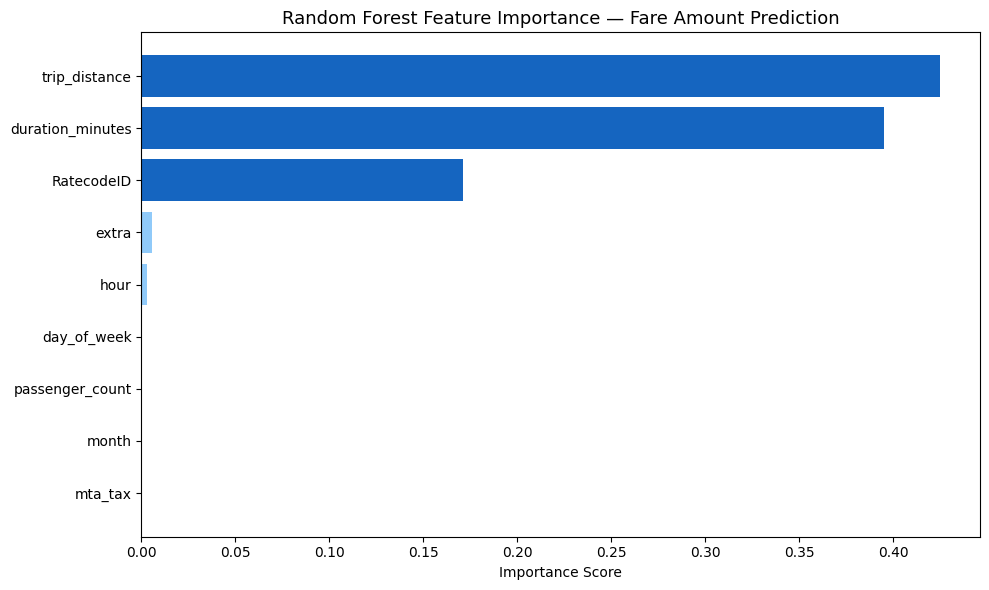

In [10]:
import pandas as pd
import matplotlib.pyplot as plt

# Extract the RandomForestRegressionModel from inside the Pipeline
rf_model = rf_pipeline_model.stages[-1]

importances = rf_model.featureImportances.toArray()

feat_df = pd.DataFrame({
    "Feature": FEATURES,
    "Importance": importances
}).sort_values("Importance", ascending=False).reset_index(drop=True)

print(feat_df.to_string(index=False))

plt.figure(figsize=(10, 6))
colors = ["#1565C0" if i < 3 else "#90CAF9" for i in range(len(feat_df))]
plt.barh(feat_df["Feature"][::-1], feat_df["Importance"][::-1], color=colors[::-1])
plt.title("Random Forest Feature Importance — Fare Amount Prediction", fontsize=13)
plt.xlabel("Importance Score")
plt.tight_layout()
plt.savefig("rf_feature_importance.png", dpi=150)
plt.show()

## 8️⃣ Save Model

In [11]:
# Save the full Pipeline (assembler + RF bundled) — load with PipelineModel.load()
rf_pipeline_model.write().overwrite().save("rf_fare_pipeline_model")
print(" Model saved to: rf_fare_pipeline_model/")

 Model saved to: rf_fare_pipeline_model/


In [12]:
import shutil

folder_name = 'rf_fare_pipeline_model'
output_filename = 'rf_fare_pipeline_model'

shutil.make_archive(output_filename, 'zip', folder_name)
print(f" تم ضغط الفولدر بنجاح: {output_filename}.zip")

 تم ضغط الفولدر بنجاح: rf_fare_pipeline_model.zip


In [13]:
from google.colab import files
files.download('rf_fare_pipeline_model.zip')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [14]:
import json
from google.colab import files


rf_model = rf_pipeline_model.stages[-1]

model_data = {
    "model_type": "RandomForestRegressor",
    "num_trees": rf_model.getNumTrees,
    "max_depth": rf_model.getOrDefault("maxDepth"),
    "features_order": FEATURES,
    "feature_importances": [float(x) for x in rf_model.featureImportances.toArray()]
}


with open("rf_fare_model.json", "w") as f:
    json.dump(model_data, f, indent=4)

print(" Model saved: 'rf_fare_model.json'")


files.download("rf_fare_model.json")

✅ Model saved: 'rf_fare_model.json'


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>